In [1]:
!pip install tree-sitter-python tree-sitter autopep8 sentence_transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.6/575.6 kB 13.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uni

# Diversity analysis

In [2]:
from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform, euclidean
from scipy.sparse.csgraph import minimum_spanning_tree
from math import log

# Define a function to get embeddings
def get_embedding(code, model, tokenizer, device):
    inputs = tokenizer.encode(code, return_tensors="pt").to(device)
    with torch.no_grad():
        embedding = model(inputs)[0].cpu().numpy()
    return embedding.reshape(1, -1)


def compute_cosine_similarity(embeddings):
    return cosine_similarity(embeddings)


def cluster_nodes(similarity_matrix, threshold=0.95):
    # Convert similarity matrix to distance matrix
    distance_matrix = 1 - similarity_matrix
    distance_matrix = np.clip(distance_matrix, 0, None)

    # Use hierarchical clustering
    condensed_distance_matrix = squareform(distance_matrix)
    Z = linkage(condensed_distance_matrix, method='complete')

    clusters = fcluster(Z, t=1-threshold, criterion='distance')

    # Collect nodes into clusters
    node_clusters = {}
    for node, cluster_id in enumerate(clusters):
        if cluster_id not in node_clusters:
            node_clusters[cluster_id] = []
        node_clusters[cluster_id].append(node)

    return list(node_clusters.values())


def calculate_shannon_diversity(clusters, total_nodes):
    proportions = [len(cluster) / total_nodes for cluster in clusters]
    shannon_index = -sum(p * log(p) for p in proportions if p > 0)
    return shannon_index


def shannon_diversity(embeddings, threshold):
    embeddings_2d = np.vstack(embeddings)

    # Compute similarity matrix
    similarity_matrix = compute_cosine_similarity(embeddings_2d)
    np.fill_diagonal(similarity_matrix, 1)
    #print(similarity_matrix)

    # Cluster nodes with a similarity threshold
    clusters = cluster_nodes(similarity_matrix, threshold)

    # Calculate Shannon Diversity Index
    total_nodes = len(embeddings)
    shannon_diversity_index = calculate_shannon_diversity(clusters, total_nodes)

    print("Clusters:", clusters)
    print("Shannon Diversity Index:", shannon_diversity_index)
    return shannon_diversity_index


def total_diversity(embeddings):
    embeddings_1d = np.vstack([emb.flatten() for emb in embeddings])  # Ensure 1D embeddings

    # Compute the distance matrix
    n = len(embeddings_1d)
    distance_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            distance = euclidean(embeddings_1d[i], embeddings_1d[j])
            distance_matrix[i, j] = distance
            distance_matrix[j, i] = distance

    # Find the Minimum Spanning Tree (MST)
    mst = minimum_spanning_tree(distance_matrix).toarray()

    # Calculate the diversity index
    mst_distances = mst[mst != 0]
    total_distance = np.sum(mst_distances)

    proportions = mst_distances / total_distance
    diversity_index = -np.sum(proportions * np.log(proportions))

    print(f"CDI: {diversity_index}")
    return diversity_index

# Model and tokenizer setup
checkpoint = "Salesforce/codet5p-110m-embedding"
device = "cuda"  # Use "cuda" if you have a GPU
tokenizer = AutoTokenizer.from_pretrained(checkpoint, trust_remote_code=True)
model = AutoModel.from_pretrained(checkpoint, trust_remote_code=True).to(device)

def get_static(code_snippets, threshold):
    # Get embeddings for all code snippets
    embeddings = [get_embedding(code, model, tokenizer, device) for code in code_snippets]

    shannon_diversity_index = shannon_diversity(embeddings, threshold=threshold)
    CID = total_diversity(embeddings)
    return shannon_diversity_index, CID


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/Salesforce/codet5p-110m-embedding:
- configuration_codet5p_embedding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_codet5p_embedding.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Salesforce/codet5p-110m-embedding:
- modeling_codet5p_embedding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
2025-06-27 10:56:29.270886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751021789.495399      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751021789.557005      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

In [3]:
import os
import autopep8
import tempfile
import json
import re

import tree_sitter_python as tspython
from tree_sitter import Language, Parser

PY_LANGUAGE = Language(tspython.language())
parser = Parser(PY_LANGUAGE)

def format_python_code(code_str):
    # Write the code string to a temporary file
    with tempfile.NamedTemporaryFile('w', delete=False, suffix='.py') as temp_file:
        temp_file.write(code_str)
        temp_filename = temp_file.name

    # Format the file using autopep8
    autopep8_args = ['--in-place', '--aggressive', '--aggressive', temp_filename]
    autopep8.fix_file(temp_filename, options=autopep8.parse_args(autopep8_args))

    # Read the formatted code from the file
    with open(temp_filename, 'r') as temp_file:
        formatted_code = temp_file.read()

    return formatted_code

def remove_comments_and_docstrings(code):
    tree = parser.parse(bytes(code, "utf8"))
    root_node = tree.root_node

    lines = code.split('\n')
    to_remove = []

    def is_comment(node):
        return node.type == 'comment'

    def is_docstring(node):
        return (node.type == 'string' and
                (node.parent.type in ['expression_statement', 'module']))

    def traverse(node):
        if is_comment(node):
            to_remove.append((node.start_point, node.end_point))
        elif is_docstring(node):
            to_remove.append((node.start_point, node.end_point))
        for child in node.children:
            traverse(child)

    traverse(root_node)

    for start, end in reversed(to_remove):
        start_row, start_col = start
        end_row, end_col = end
        if start_row == end_row:
            lines[start_row] = lines[start_row][:start_col] + lines[start_row][end_col:]
        else:
            lines[start_row] = lines[start_row][:start_col]
            for row in range(start_row + 1, end_row):
                lines[row] = ''
            lines[end_row] = lines[end_row][end_col:]

    cleaned_lines = [line for line in lines if line.strip() != '']

    return '\n'.join(cleaned_lines)

## Utils function

In [4]:
def read_all_files_in_folder(folder_path, framework_name, parsed_data):
    if 'funsearch' in framework_name:
        folder_path = os.path.join(folder_path, 'samples')
    files = os.listdir(folder_path)
    lstcode = dict()

    for file_name in files:
        file_path = os.path.join(folder_path, file_name)
        file_name_without_ext = os.path.splitext(file_name)[0]
    
        # Điều kiện lọc file
        if ('hsevo' in framework_name or 'reevo' in framework_name) \
            and ('_response' in file_name_without_ext or '_hs' in file_name_without_ext) \
            and '_prompt' not in file_name_without_ext \
            and 'objs_log_' not in file_name_without_ext:
            
            try:
                # Thử đọc file bằng utf-8, nếu lỗi thì dùng latin1
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        content = file.read()
                except UnicodeDecodeError:
                    with open(file_path, 'r', encoding='latin1') as file:
                        content = file.read()
    
                # Nếu không phải stdout
                if '.txt_stdout' not in file_name_without_ext:
                    # Loại bỏ các dấu ```python và ``` markdown
                    cleaned_content = content.replace('```python', '').replace('```', '')
                    lstcode[file_name_without_ext] = cleaned_content
    
                # Nếu là stdout mà không chứa '[*] Average:', thì xóa key tương ứng
                elif '.txt_stdout' in file_name_without_ext and "[*] Average:" not in content:
                    # Có thể phải cắt thêm đuôi nếu double split
                    cleaned_name = os.path.splitext(file_name_without_ext)[0]
                    if cleaned_name in lstcode:
                        lstcode.pop(cleaned_name)
    
            except Exception as e:
                print(f'❌ Could not read {file_name}: {e}')
        if 'funsearch' in framework_name:
            id_sample = file_name_without_ext.split('_')[1]

            if(int(id_sample) <= 330):
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        content = file.read()
                        content = json.loads(content)
                        if content['score']:
                            lstcode[file_name_without_ext] = content['function']
                            excess = (-content['score'] - l1_bound) / l1_bound * 100
                            parsed_data[int(id_sample)] = parsed_data[int(id_sample)] + (excess,)
                except Exception as e:
                    print(f'Could not read {file_name}: {e}')

    return lstcode

def parse_log(log_string):
  best_obj_pattern = re.compile(r"Best obj: (-?[\d\.]+)")
  tokens_pattern = re.compile(r"prompt_tokens = (\d+), completion_tokens = (\d+)")


  best_objs = best_obj_pattern.findall(log_string)
  tokens_matches = tokens_pattern.findall(log_string)

  results = []
  for i in range(max(len(best_objs), len(tokens_matches))):
      prompt_tokens = int(tokens_matches[i][0])
      completion_tokens = int(tokens_matches[i][1])
      total_tokens = prompt_tokens + completion_tokens
      try:
          best_obj = float(best_objs[i])
      except:
          best_obj = None

      if best_obj is not None:
        results.append((total_tokens, best_obj))
      else:
        results.append((total_tokens, ))

  return results

In [5]:
def create_sets_from_data(data, group_size=10):
    result = []
    min_second = float('inf')
    for i in range(0, len(data), group_size):
        group = data[i:i+group_size]
        max_first = max(item[0] for item in group)

        # Update the minimum value for the second position, considering all elements from the start to the current group
        for item in data[:i+len(group)]:
            if len(item) > 1:  # Check if there's a second position
                min_second = min(min_second, item[1])
        result.append((max_first, min_second))

    return result

def create_sets_from_data_eoh(parsed_data, num_init, obj_eoh):
    num_gen = len(obj_eoh)
    # Step 1: Group the first `num_init` elements and get the max value of this group
    first_group = max(parsed_data[:num_init])[0]

    # Step 2: Calculate the number of elements in each subsequent group
    remaining_elements = len(parsed_data) - num_init
    group_size = remaining_elements // num_gen

    # Step 3: Initialize the list to store the result
    result = [(first_group, 0)]

    # Step 4: Group the remaining elements and get the max value of each group
    for i in range(num_gen):
        start_index = num_init + i * group_size
        end_index = start_index + group_size
        group = parsed_data[start_index:end_index]
        max_value = max(group)[0]
        result.append((max_value, obj_eoh[i]*100))

    return result

def get_max_obj_eoh(folder_path):
    lst_obj_eoh = []
    folder_path += "/pops_best"
    files = os.listdir(folder_path)

    for file_name in files:
        file_path = os.path.join(folder_path, file_name)
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                content = json.loads(content)
                lst_obj_eoh.append(content['objective'])
        except Exception as e:
            print(f'Could not read {file_name}: {e}')
    return lst_obj_eoh


def get_init_eoh(folder_path):
    lstcode = dict()
    init_logs = folder_path + "/pops/population_generation_0.json"
    with open(init_logs, 'r', encoding='utf-8') as file:
        content = file.read()
        content = json.loads(content)
        for idx, data in enumerate(content):
            if data['objective']:
                name_idv = "pop_0_off" + str(idx) + "_i0"
                lstcode[name_idv] = data['code']
    return lstcode

def eoh_preprocess(folder_path, parsed_data):
    # List all files in the folder
    lstcode = get_init_eoh(folder_path)

    folder_path += "/history"
    files = os.listdir(folder_path)

    for file_name in files:
        file_path = os.path.join(folder_path, file_name)
        file_name_without_ext = os.path.splitext(file_name)[0]

        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read()
                content = json.loads(content)
                if content['offspring']['objective']:
                    lstcode[file_name_without_ext] = content['offspring']['code']
        except Exception as e:
            print(f'Could not read {file_name}: {e}')

    return lstcode

# HSEVO-TSP_ACO-1

In [12]:
log_run = {
        "name": "hsevo_1",
        "path": "/kaggle/input/eoh-output/hsevo-tsp_aco-1"
}


f = open(log_run["path"] + '/main.log', "r")
data = f.read().split('\n')
f.close()
raw_string = ''
for idl in range(len(data)):
  if "hsevo" in log_run["name"] or "reevo" in log_run["name"]:
    if 'Best obj:' in data[idl]:
      raw_string += data[idl] + '\n' + data[idl+1] + '\n'
  elif "funsearch" in log_run["name"] or "eoh" in log_run["name"]:
    match = re.search(r"l1_bound:\s*([\d.]+)", data[0])
    if match:
      l1_bound = float(match.group(1))
      raw_string = '\n'.join(data[1:])
    else:
      raw_string = '\n'.join(data)



if "eoh" in log_run["name"]:
    parsed_data = parse_log(raw_string)
    lstcode = eoh_preprocess(log_run["path"], parsed_data)
    lst_init_eoh = get_init_eoh(log_run["path"])
    obj_eoh = get_max_obj_eoh(log_run["path"])
    parsed_data = create_sets_from_data_eoh(parsed_data, len(lst_init_eoh), obj_eoh)
elif "funsearch" in log_run["name"]:
    parsed_data = create_sets_from_data(parsed_data, 20)
else:
    parsed_data = parse_log(raw_string)

lstcode = read_all_files_in_folder(log_run["path"], log_run["name"], parsed_data)
for name, code in lstcode.items():
    # 1. Format code following PEP8
    formatted_code = format_python_code(code)

    # 2. Remove comments and docstrings in code
    cleaned_code = remove_comments_and_docstrings(formatted_code)
    lstcode[name] = cleaned_code

In [13]:
from collections import defaultdict

def group_names(lstcode, framework_name, base = 20):
    grouped_lists = defaultdict(list)

    # Regular expression patterns
    pattern_hsevo = re.compile(r'problem_iter(\d+)')
    pattern_reevo = re.compile(r'problem_iter(\d+)')
    pattern_funsearch = re.compile(r'samples_(\d+)')
    pattern_eoh = re.compile(r'pop_(\d+)')

    for name in lstcode.keys():
        log_run = lstcode[name]

        if "hsevo" in framework_name:
            match = pattern_reevo.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)
        elif "reevo" in framework_name:
            match = pattern_reevo.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)
        elif "funsearch" in framework_name:
            match = pattern_funsearch.match(name)
            if match:
                i = int(match.group(1)) - 1
                group_key = i // base
                grouped_lists[group_key].append(name)
        elif "eoh" in framework_name:
            match = pattern_eoh.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)

    for key in sorted(grouped_lists.keys()):
        print(f"List for group {key}:", grouped_lists[key])
    print("---------------\n\n")

    return grouped_lists

if "eoh" in log_run["name"]:
    grouped_lists = group_names(lstcode, "eoh")
elif "funsearch" in log_run["name"]:
    grouped_lists = group_names(lstcode, "funsearch", 20)
elif "hsevo" in log_run["name"]:
    grouped_lists = group_names(lstcode, "hsevo")
elif "reevo" in log_run["name"]:
    grouped_lists = group_names(lstcode, "reevo")
else:
    print("Group list error!")

SWDI_lst = []
CDI_lst = []

lst_pop = []

for key in sorted(grouped_lists.keys()):
    print(f"List for i group {key}:", grouped_lists[key])
    code_snippets = [lstcode[name] for name in grouped_lists[key]]
    lst_pop.extend(code_snippets)
    a,b = get_static(lst_pop, 0.95)
    print(key)
    print(parsed_data)
    parsed_data[key] = parsed_data[key] + (a, b,)
    SWDI_lst.append(a)
    CDI_lst.append(b)
    print("---------------\n")

print("SWDI:", SWDI_lst)
print("CDI:", CDI_lst)

List for group 1: ['problem_iter1_response5', 'problem_iter1_response0', 'problem_iter1_response25', 'problem_iter1_response14', 'problem_iter1_response12', 'problem_iter1_response19', 'problem_iter1_response28', 'problem_iter1_response2', 'problem_iter1_response9', 'problem_iter1_response3', 'problem_iter1_response20', 'problem_iter1_response26', 'problem_iter1_response7', 'problem_iter1_response4', 'problem_iter1_response17', 'problem_iter1_response21', 'problem_iter1_response23', 'problem_iter1_response13', 'problem_iter1_response1', 'problem_iter1_response15', 'problem_iter1_response29', 'problem_iter1_response24', 'problem_iter1_response6']
List for group 2: ['problem_iter2_response4', 'problem_iter2_response6', 'problem_iter2_response1', 'problem_iter2_response5', 'problem_iter2_response3', 'problem_iter2_response9', 'problem_iter2_response7', 'problem_iter2_response2', 'problem_iter2_response0']
List for group 3: ['problem_iter3_response3', 'problem_iter3_response0', 'problem_it

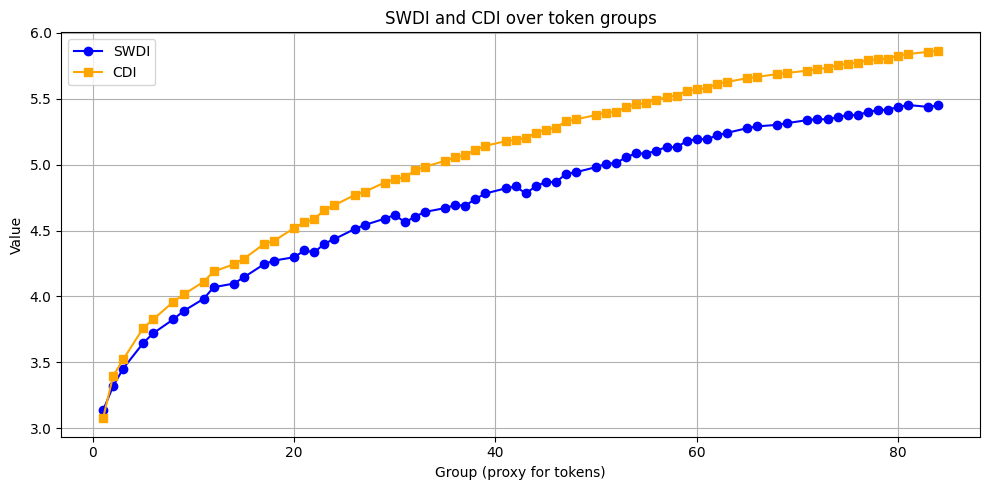

In [14]:
import matplotlib.pyplot as plt

# Trục X là chỉ số token/group key
x = sorted(grouped_lists.keys())

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

# Vẽ đường cho SWDI
plt.plot(x, SWDI_lst, marker='o', label='SWDI', color='blue')

# Vẽ đường cho CDI
plt.plot(x, CDI_lst, marker='s', label='CDI', color='orange')

# Thiết lập nhãn và tiêu đề
plt.xlabel('Group (proxy for tokens)')
plt.ylabel('Value')
plt.title('SWDI and CDI over token groups')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

In [15]:
parsed_data

[(0, 6.585536802937204),
 (24070, 5.934237871070863, 3.1354942159291497, 3.0759059687430166),
 (37277, 5.895997791148219, 3.319419301952094, 3.3965541406394317),
 (38343, 5.859629736751106, 3.45345973770266, 3.522193643805988),
 (40412, 5.859629736751106),
 (59426, 5.859629736751106, 3.6478203928647597, 3.761551271939522),
 (60886, 5.859629736751106, 3.722069968177582, 3.8277889442420996),
 (63203, 5.859629736751106),
 (91031, 5.847546380977086, 3.8273096391465913, 3.9603583001788727),
 (92118, 5.847546380977086, 3.889565327143698, 4.015337167698815),
 (94946, 5.847546380977086),
 (123000, 5.847546380977086, 3.98243881989442, 4.111794737477658),
 (124101, 5.847546380977086, 4.070257395619661, 4.189496874688035),
 (126688, 5.847546380977086),
 (153169, 5.847546380977086, 4.097994309794454, 4.244389714071787),
 (154315, 5.847546380977086, 4.145763370265123, 4.2863428630664),
 (157225, 5.847546380977086),
 (187643, 5.847546380977086, 4.2447911718981715, 4.398303219248738),
 (189005, 5.847

In [16]:
def find_nearest_best_obj(results, step=25000):
    results.sort(key=lambda x: x[0])  # Sort by total_tokens
    step_tokens = 0
    nearest_objs = []

    while step_tokens <= results[-1][0]:  # Iterate until the maximum total_tokens
        nearest = min(results, key=lambda x: abs(x[0] - step_tokens))
        # Extract the last 3 elements from the nearest tuple
        nearest_objs.append((step_tokens, abs(nearest[-3]), nearest[-2], nearest[-1]))
        step_tokens += step

    return nearest_objs

def fill_missing_elements(data):
    if data[0][0] == 0:
        data[0] = (data[0][0], data[0][1], 0, 0)
    for i in range(1, len(data)):
        if len(data[i]) == 2:
            data[i] = (
                data[i][0],
                data[i][1],
                data[i-1][2],
                data[i-1][3]
            )
    return data

parsed_data = fill_missing_elements(parsed_data)
nearest_objs = find_nearest_best_obj(parsed_data, 25000)
nearest_objs

[(0, 6.585536802937204, 0, 0),
 (25000, 5.934237871070863, 3.1354942159291497, 3.0759059687430166),
 (50000, 5.859629736751106, 3.6478203928647597, 3.761551271939522),
 (75000, 5.859629736751106, 3.722069968177582, 3.8277889442420996),
 (100000, 5.847546380977086, 3.889565327143698, 4.015337167698815),
 (125000, 5.847546380977086, 4.070257395619661, 4.189496874688035),
 (150000, 5.847546380977086, 4.097994309794454, 4.244389714071787),
 (175000, 5.847546380977086, 4.2447911718981715, 4.398303219248738),
 (200000, 5.847546380977086, 4.27254332931277, 4.4224058047736285),
 (225000, 5.847546380977086, 4.334099183100626, 4.588264555453267),
 (250000, 5.847546380977086, 4.401550888870768, 4.655343694371073),
 (275000, 5.847546380977086, 4.511056064447852, 4.769694379743395),
 (300000, 5.847546380977086, 4.542149953544175, 4.794603526945721),
 (325000, 5.847546380977086, 4.618805042151667, 4.887213137709793),
 (350000, 5.847546380977086, 4.604699817423144, 4.955799602679345),
 (375000, 5.847

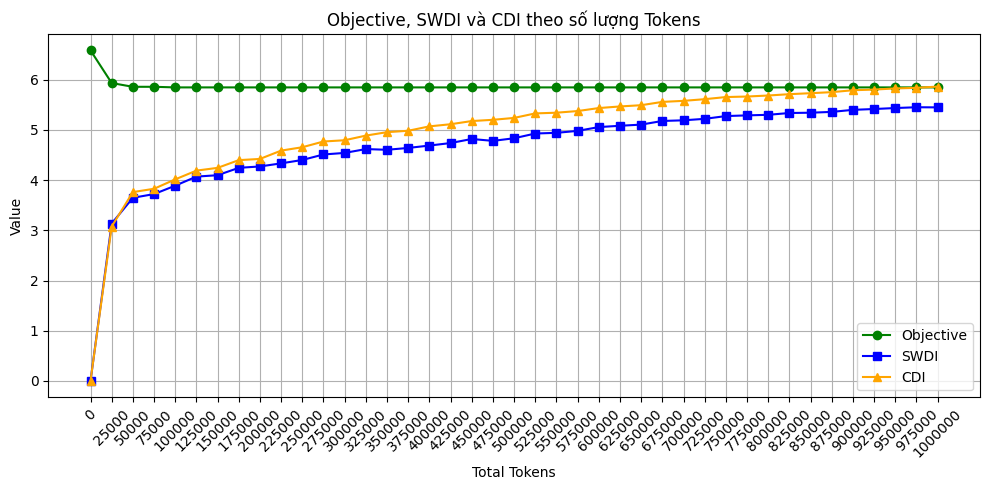

In [17]:
import matplotlib.pyplot as plt

# Ép tokens thành kiểu int
tokens = [int(x[0]) for x in nearest_objs]
objs = [x[1] for x in nearest_objs]
SWDI = [x[2] for x in nearest_objs]
CDI = [x[3] for x in nearest_objs]

plt.figure(figsize=(10, 5))

plt.plot(tokens, objs, marker='o', label='Objective', color='green')
plt.plot(tokens, SWDI, marker='s', label='SWDI', color='blue')
plt.plot(tokens, CDI, marker='^', label='CDI', color='orange')

plt.xlabel('Total Tokens')
plt.ylabel('Value')
plt.title('Objective, SWDI và CDI theo số lượng Tokens')
plt.xticks(tokens, rotation=45)  # Đảm bảo matplotlib hiển thị đúng tokens
plt.ticklabel_format(style='plain', axis='x')  # <--- không dùng định dạng khoa học (1e6)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# HSEVO-TSP_ACO-2

In [18]:
log_run = {
        "name": "hsevo_1",
        "path": "/kaggle/input/eoh-output/hsevo-tsp_aco-2"
}


f = open(log_run["path"] + '/main.log', "r")
data = f.read().split('\n')
f.close()
raw_string = ''
for idl in range(len(data)):
  if "hsevo" in log_run["name"] or "reevo" in log_run["name"]:
    if 'Best obj:' in data[idl]:
      raw_string += data[idl] + '\n' + data[idl+1] + '\n'
  elif "funsearch" in log_run["name"] or "eoh" in log_run["name"]:
    match = re.search(r"l1_bound:\s*([\d.]+)", data[0])
    if match:
      l1_bound = float(match.group(1))
      raw_string = '\n'.join(data[1:])
    else:
      raw_string = '\n'.join(data)



if "eoh" in log_run["name"]:
    parsed_data = parse_log(raw_string)
    lstcode = eoh_preprocess(log_run["path"], parsed_data)
    lst_init_eoh = get_init_eoh(log_run["path"])
    obj_eoh = get_max_obj_eoh(log_run["path"])
    parsed_data = create_sets_from_data_eoh(parsed_data, len(lst_init_eoh), obj_eoh)
elif "funsearch" in log_run["name"]:
    parsed_data = create_sets_from_data(parsed_data, 20)
else:
    parsed_data = parse_log(raw_string)

lstcode = read_all_files_in_folder(log_run["path"], log_run["name"], parsed_data)
for name, code in lstcode.items():
    # 1. Format code following PEP8
    formatted_code = format_python_code(code)

    # 2. Remove comments and docstrings in code
    cleaned_code = remove_comments_and_docstrings(formatted_code)
    lstcode[name] = cleaned_code

In [19]:
from collections import defaultdict

def group_names(lstcode, framework_name, base = 20):
    grouped_lists = defaultdict(list)

    # Regular expression patterns
    pattern_hsevo = re.compile(r'problem_iter(\d+)')
    pattern_reevo = re.compile(r'problem_iter(\d+)')
    pattern_funsearch = re.compile(r'samples_(\d+)')
    pattern_eoh = re.compile(r'pop_(\d+)')

    for name in lstcode.keys():
        log_run = lstcode[name]

        if "hsevo" in framework_name:
            match = pattern_reevo.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)
        elif "reevo" in framework_name:
            match = pattern_reevo.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)
        elif "funsearch" in framework_name:
            match = pattern_funsearch.match(name)
            if match:
                i = int(match.group(1)) - 1
                group_key = i // base
                grouped_lists[group_key].append(name)
        elif "eoh" in framework_name:
            match = pattern_eoh.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)

    for key in sorted(grouped_lists.keys()):
        print(f"List for group {key}:", grouped_lists[key])
    print("---------------\n\n")

    return grouped_lists

if "eoh" in log_run["name"]:
    grouped_lists = group_names(lstcode, "eoh")
elif "funsearch" in log_run["name"]:
    grouped_lists = group_names(lstcode, "funsearch", 20)
elif "hsevo" in log_run["name"]:
    grouped_lists = group_names(lstcode, "hsevo")
elif "reevo" in log_run["name"]:
    grouped_lists = group_names(lstcode, "reevo")
else:
    print("Group list error!")

SWDI_lst = []
CDI_lst = []

lst_pop = []

for key in sorted(grouped_lists.keys()):
    print(f"List for i group {key}:", grouped_lists[key])
    code_snippets = [lstcode[name] for name in grouped_lists[key]]
    lst_pop.extend(code_snippets)
    a,b = get_static(lst_pop, 0.95)
    print(key)
    print(parsed_data)
    parsed_data[key] = parsed_data[key] + (a, b,)
    SWDI_lst.append(a)
    CDI_lst.append(b)
    print("---------------\n")

print("SWDI:", SWDI_lst)
print("CDI:", CDI_lst)

List for group 1: ['problem_iter1_response27', 'problem_iter1_response25', 'problem_iter1_response19', 'problem_iter1_response28', 'problem_iter1_response2', 'problem_iter1_response9', 'problem_iter1_response3', 'problem_iter1_response20', 'problem_iter1_response26', 'problem_iter1_response7', 'problem_iter1_response4', 'problem_iter1_response17', 'problem_iter1_response21', 'problem_iter1_response23', 'problem_iter1_response13', 'problem_iter1_response1', 'problem_iter1_response15', 'problem_iter1_response29', 'problem_iter1_response24', 'problem_iter1_response6']
List for group 2: ['problem_iter2_response8', 'problem_iter2_response4', 'problem_iter2_response6', 'problem_iter2_response1', 'problem_iter2_response5', 'problem_iter2_response3', 'problem_iter2_response9', 'problem_iter2_response7', 'problem_iter2_response2', 'problem_iter2_response0']
List for group 3: ['problem_iter3_response0', 'problem_iter3_response4', 'problem_iter3_response1']
List for group 5: ['problem_iter5_respo

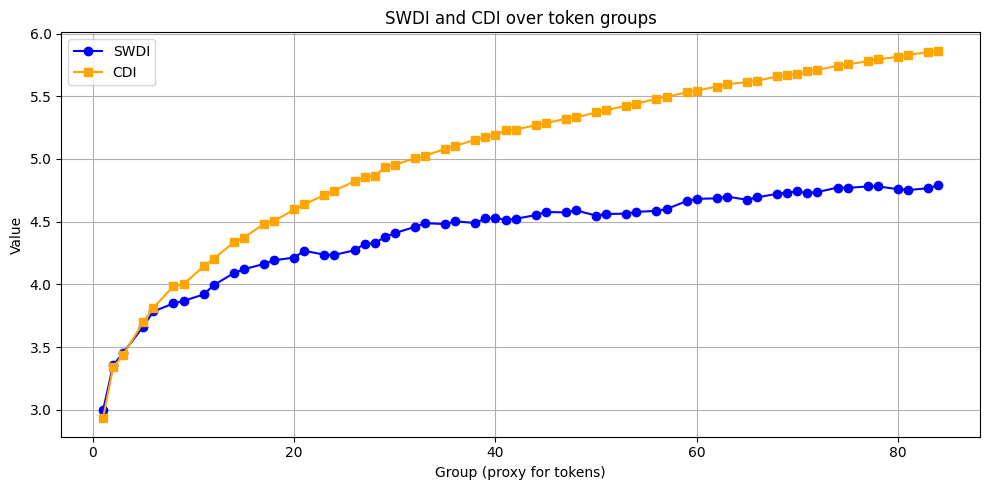

In [22]:
import matplotlib.pyplot as plt

# Trục X là chỉ số token/group key
x = sorted(grouped_lists.keys())

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

# Vẽ đường cho SWDI
plt.plot(x, SWDI_lst, marker='o', label='SWDI', color='blue')

# Vẽ đường cho CDI
plt.plot(x, CDI_lst, marker='s', label='CDI', color='orange')

# Thiết lập nhãn và tiêu đề
plt.xlabel('Group (proxy for tokens)')
plt.ylabel('Value')
plt.title('SWDI and CDI over token groups')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

In [21]:
parsed_data

[(0, 6.385248337822795, 0, 0),
 (32576, 6.385248337822795, 2.995732273553991, 2.932768379741202),
 (46337, 6.385248337822795, 3.3549875696248246, 3.338245738754541),
 (47112, 6.385248337822795, 3.4544986414325436, 3.439033581752889),
 (49092, 6.385248337822795, 3.4544986414325436, 3.439033581752889),
 (66943, 6.285468020291772, 3.6644819044526424, 3.699790050714699),
 (68083, 6.285468020291772, 3.784557613337901, 3.8144971701866788),
 (70265, 6.285468020291772, 3.784557613337901, 3.8144971701866788),
 (94361, 6.170555123418916, 3.848483638203691, 3.9853524656960913),
 (95931, 6.170555123418916, 3.8692299952195346, 4.003270902785078),
 (98846, 6.170555123418916, 3.8692299952195346, 4.003270902785078),
 (125461, 6.063896992650427, 3.9200907838374204, 4.143491924372954),
 (127077, 6.063896992650427, 3.9941119477161378, 4.2050897607420135),
 (130015, 6.063896992650427, 3.9941119477161378, 4.2050897607420135),
 (161084, 6.063896992650427, 4.090578779035803, 4.335881910459462),
 (162680, 6.0

In [20]:
def find_nearest_best_obj(results, step=25000):
    results.sort(key=lambda x: x[0])  # Sort by total_tokens
    step_tokens = 0
    nearest_objs = []

    while step_tokens <= results[-1][0]:  # Iterate until the maximum total_tokens
        nearest = min(results, key=lambda x: abs(x[0] - step_tokens))
        # Extract the last 3 elements from the nearest tuple
        nearest_objs.append((step_tokens, abs(nearest[-3]), nearest[-2], nearest[-1]))
        step_tokens += step

    return nearest_objs

def fill_missing_elements(data):
    if data[0][0] == 0:
        data[0] = (data[0][0], data[0][1], 0, 0)
    for i in range(1, len(data)):
        if len(data[i]) == 2:
            data[i] = (
                data[i][0],
                data[i][1],
                data[i-1][2],
                data[i-1][3]
            )
    return data

parsed_data = fill_missing_elements(parsed_data)
nearest_objs = find_nearest_best_obj(parsed_data, 25000)
nearest_objs

[(0, 6.385248337822795, 0, 0),
 (25000, 6.385248337822795, 2.995732273553991, 2.932768379741202),
 (50000, 6.385248337822795, 3.4544986414325436, 3.439033581752889),
 (75000, 6.285468020291772, 3.784557613337901, 3.8144971701866788),
 (100000, 6.170555123418916, 3.8692299952195346, 4.003270902785078),
 (125000, 6.063896992650427, 3.9200907838374204, 4.143491924372954),
 (150000, 6.063896992650427, 4.090578779035803, 4.335881910459462),
 (175000, 6.063896992650427, 4.121295432323226, 4.373766724811412),
 (200000, 6.063896992650427, 4.163466534232493, 4.482967463373154),
 (225000, 6.063896992650427, 4.192433031931107, 4.5045932694705835),
 (250000, 6.063896992650427, 4.268024639542728, 4.637393936971066),
 (275000, 6.063896992650427, 4.237306360124526, 4.713744937686366),
 (300000, 6.063896992650427, 4.235667570380185, 4.747759584101498),
 (325000, 6.063896992650427, 4.272534343125326, 4.822360686121509),
 (350000, 6.063896992650427, 4.330381906558733, 4.86609931278692),
 (375000, 6.0638

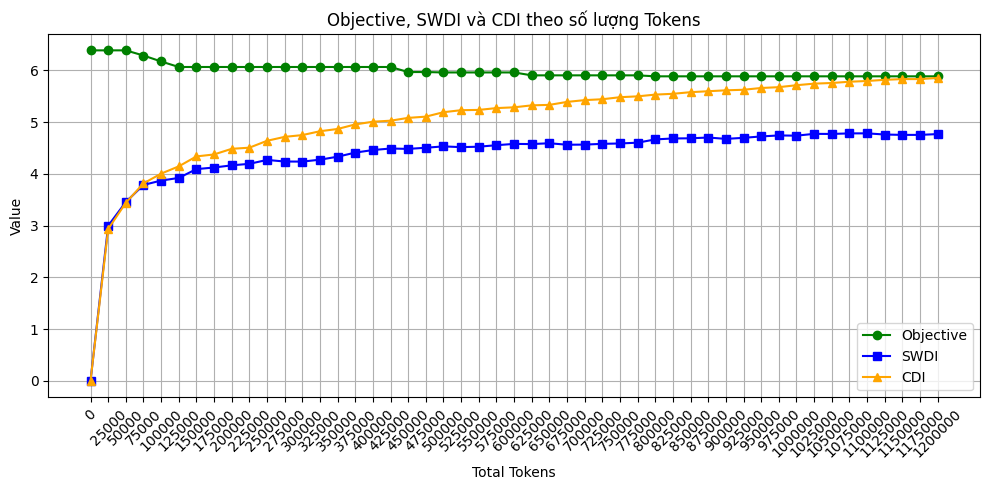

In [24]:
import matplotlib.pyplot as plt

# Ép tokens thành kiểu int
tokens = [int(x[0]) for x in nearest_objs]
objs = [x[1] for x in nearest_objs]
SWDI = [x[2] for x in nearest_objs]
CDI = [x[3] for x in nearest_objs]

plt.figure(figsize=(10, 5))

plt.plot(tokens, objs, marker='o', label='Objective', color='green')
plt.plot(tokens, SWDI, marker='s', label='SWDI', color='blue')
plt.plot(tokens, CDI, marker='^', label='CDI', color='orange')

plt.xlabel('Total Tokens')
plt.ylabel('Value')
plt.title('Objective, SWDI và CDI theo số lượng Tokens')
plt.xticks(tokens, rotation=45)  # Đảm bảo matplotlib hiển thị đúng tokens
plt.ticklabel_format(style='plain', axis='x')  # <--- không dùng định dạng khoa học (1e6)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# HSEVO-TSP_ACO-3

In [6]:
log_run = {
        "name": "hsevo_1",
        "path": "/kaggle/input/eoh-output/hsevo-tsp_aco-3"
}


f = open(log_run["path"] + '/main.log', "r", encoding="utf-8", errors="ignore")
data = f.read().split('\n')
f.close()
raw_string = ''
for idl in range(len(data)):
  if "hsevo" in log_run["name"] or "reevo" in log_run["name"]:
    if 'Best obj:' in data[idl]:
      raw_string += data[idl] + '\n' + data[idl+1] + '\n'
  elif "funsearch" in log_run["name"] or "eoh" in log_run["name"]:
    match = re.search(r"l1_bound:\s*([\d.]+)", data[0])
    if match:
      l1_bound = float(match.group(1))
      raw_string = '\n'.join(data[1:])
    else:
      raw_string = '\n'.join(data)



if "eoh" in log_run["name"]:
    parsed_data = parse_log(raw_string)
    lstcode = eoh_preprocess(log_run["path"], parsed_data)
    lst_init_eoh = get_init_eoh(log_run["path"])
    obj_eoh = get_max_obj_eoh(log_run["path"])
    parsed_data = create_sets_from_data_eoh(parsed_data, len(lst_init_eoh), obj_eoh)
elif "funsearch" in log_run["name"]:
    parsed_data = create_sets_from_data(parsed_data, 20)
else:
    parsed_data = parse_log(raw_string)

lstcode = read_all_files_in_folder(log_run["path"], log_run["name"], parsed_data)
for name, code in lstcode.items():
    # 1. Format code following PEP8
    formatted_code = format_python_code(code)

    # 2. Remove comments and docstrings in code
    cleaned_code = remove_comments_and_docstrings(formatted_code)
    lstcode[name] = cleaned_code

In [7]:
from collections import defaultdict

def group_names(lstcode, framework_name, base = 20):
    grouped_lists = defaultdict(list)

    # Regular expression patterns
    pattern_hsevo = re.compile(r'problem_iter(\d+)')
    pattern_reevo = re.compile(r'problem_iter(\d+)')
    pattern_funsearch = re.compile(r'samples_(\d+)')
    pattern_eoh = re.compile(r'pop_(\d+)')

    for name in lstcode.keys():
        log_run = lstcode[name]

        if "hsevo" in framework_name:
            match = pattern_reevo.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)
        elif "reevo" in framework_name:
            match = pattern_reevo.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)
        elif "funsearch" in framework_name:
            match = pattern_funsearch.match(name)
            if match:
                i = int(match.group(1)) - 1
                group_key = i // base
                grouped_lists[group_key].append(name)
        elif "eoh" in framework_name:
            match = pattern_eoh.match(name)
            if match:
                i = int(match.group(1))
                grouped_lists[i].append(name)

    for key in sorted(grouped_lists.keys()):
        print(f"List for group {key}:", grouped_lists[key])
    print("---------------\n\n")

    return grouped_lists

if "eoh" in log_run["name"]:
    grouped_lists = group_names(lstcode, "eoh")
elif "funsearch" in log_run["name"]:
    grouped_lists = group_names(lstcode, "funsearch", 20)
elif "hsevo" in log_run["name"]:
    grouped_lists = group_names(lstcode, "hsevo")
elif "reevo" in log_run["name"]:
    grouped_lists = group_names(lstcode, "reevo")
else:
    print("Group list error!")

SWDI_lst = []
CDI_lst = []

lst_pop = []

for key in sorted(grouped_lists.keys()):
    print(f"List for i group {key}:", grouped_lists[key])
    code_snippets = [lstcode[name] for name in grouped_lists[key]]
    lst_pop.extend(code_snippets)
    a,b = get_static(lst_pop, 0.95)
    print(key)
    print(parsed_data)
    parsed_data[key] = parsed_data[key] + (a, b,)
    SWDI_lst.append(a)
    CDI_lst.append(b)
    print("---------------\n")

print("SWDI:", SWDI_lst)
print("CDI:", CDI_lst)

Token indices sequence length is longer than the specified maximum sequence length for this model (1602 > 512). Running this sequence through the model will result in indexing errors


List for group 1: ['problem_iter1_response11', 'problem_iter1_response22', 'problem_iter1_response0', 'problem_iter1_response25', 'problem_iter1_response8', 'problem_iter1_response10', 'problem_iter1_response18', 'problem_iter1_response12', 'problem_iter1_response19', 'problem_iter1_response28', 'problem_iter1_response2', 'problem_iter1_response9', 'problem_iter1_response3', 'problem_iter1_response20', 'problem_iter1_response26', 'problem_iter1_response7', 'problem_iter1_response4', 'problem_iter1_response17', 'problem_iter1_response21', 'problem_iter1_response23', 'problem_iter1_response13', 'problem_iter1_response1', 'problem_iter1_response15', 'problem_iter1_response29', 'problem_iter1_response24', 'problem_iter1_response6']
List for group 2: ['problem_iter2_response8', 'problem_iter2_response4', 'problem_iter2_response1', 'problem_iter2_response5', 'problem_iter2_response3', 'problem_iter2_response9', 'problem_iter2_response7', 'problem_iter2_response2', 'problem_iter2_response0']


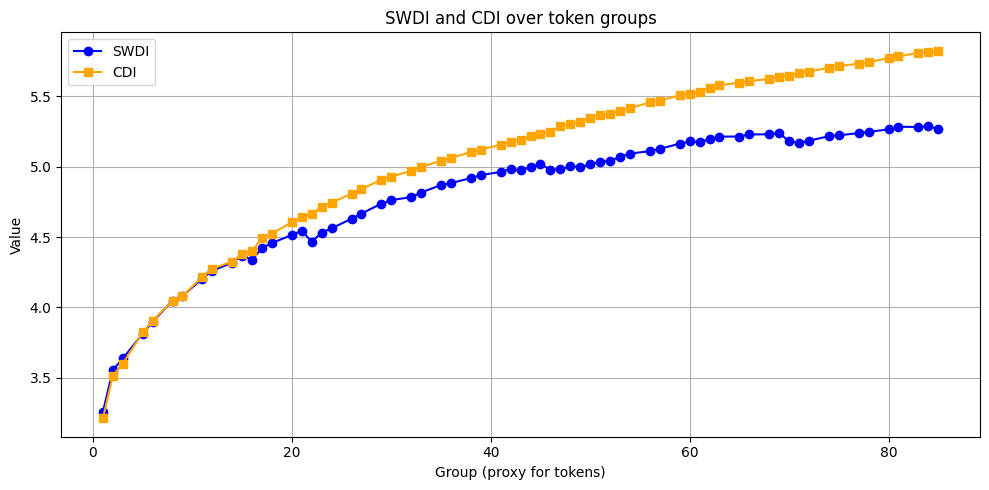

In [8]:
import matplotlib.pyplot as plt

# Trục X là chỉ số token/group key
x = sorted(grouped_lists.keys())

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

# Vẽ đường cho SWDI
plt.plot(x, SWDI_lst, marker='o', label='SWDI', color='blue')

# Vẽ đường cho CDI
plt.plot(x, CDI_lst, marker='s', label='CDI', color='orange')

# Thiết lập nhãn và tiêu đề
plt.xlabel('Group (proxy for tokens)')
plt.ylabel('Value')
plt.title('SWDI and CDI over token groups')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

In [9]:
parsed_data

[(0, 6.693265659135302),
 (30399, 6.693265659135302, 3.2580965380214835, 3.212344779809678),
 (45450, 6.693265659135302, 3.5553480614894135, 3.5158292268576337),
 (46449, 6.693265659135302, 3.637586159726386, 3.601162608572653),
 (48554, 6.693265659135302),
 (65575, 6.10594364570493, 3.8134387458612324, 3.822754424348374),
 (66606, 6.082907776204815, 3.897924704692203, 3.906346448486806),
 (68751, 6.082907776204815),
 (93916, 6.082907776204815, 4.048134750184772, 4.047506734008317),
 (95475, 6.082907776204815, 4.082415212105737, 4.081533851352442),
 (97947, 6.082907776204815),
 (126795, 6.082907776204815, 4.204104058965829, 4.218105481045405),
 (128067, 6.082907776204815, 4.262036339091507, 4.275264990910233),
 (130463, 6.082907776204815),
 (156844, 6.082907776204815, 4.316803762804243, 4.326225977835457),
 (158028, 6.082907776204815, 4.368733582695877, 4.377164033779622),
 (160884, 6.082907776204815, 4.338631443506275, 4.400917029416653),
 (188781, 6.082907776204815, 4.422761035148569

In [10]:
def find_nearest_best_obj(results, step=25000):
    results.sort(key=lambda x: x[0])  # Sort by total_tokens
    step_tokens = 0
    nearest_objs = []

    while step_tokens <= results[-1][0]:  # Iterate until the maximum total_tokens
        nearest = min(results, key=lambda x: abs(x[0] - step_tokens))
        # Extract the last 3 elements from the nearest tuple
        nearest_objs.append((step_tokens, abs(nearest[-3]), nearest[-2], nearest[-1]))
        step_tokens += step

    return nearest_objs

def fill_missing_elements(data):
    if data[0][0] == 0:
        data[0] = (data[0][0], data[0][1], 0, 0)
    for i in range(1, len(data)):
        if len(data[i]) == 2:
            data[i] = (
                data[i][0],
                data[i][1],
                data[i-1][2],
                data[i-1][3]
            )
    return data

parsed_data = fill_missing_elements(parsed_data)
nearest_objs = find_nearest_best_obj(parsed_data, 25000)
nearest_objs

[(0, 6.693265659135302, 0, 0),
 (25000, 6.693265659135302, 3.2580965380214835, 3.212344779809678),
 (50000, 6.693265659135302, 3.637586159726386, 3.601162608572653),
 (75000, 6.082907776204815, 3.897924704692203, 3.906346448486806),
 (100000, 6.082907776204815, 4.082415212105737, 4.081533851352442),
 (125000, 6.082907776204815, 4.204104058965829, 4.218105481045405),
 (150000, 6.082907776204815, 4.316803762804243, 4.326225977835457),
 (175000, 6.082907776204815, 4.422761035148569, 4.4927964974761),
 (200000, 6.082907776204815, 4.457823213703778, 4.524794872118295),
 (225000, 6.082907776204815, 4.466925022127534, 4.6627458255836425),
 (250000, 6.082907776204815, 4.531454162753392, 4.7168728261861235),
 (275000, 6.082907776204815, 4.629902105946088, 4.809098456710778),
 (300000, 6.082907776204815, 4.66713819617365, 4.840899786871589),
 (325000, 6.082907776204815, 4.762162760148248, 4.929522396535472),
 (350000, 6.082907776204815, 4.784169430421548, 4.9702826276233205),
 (375000, 6.0829077

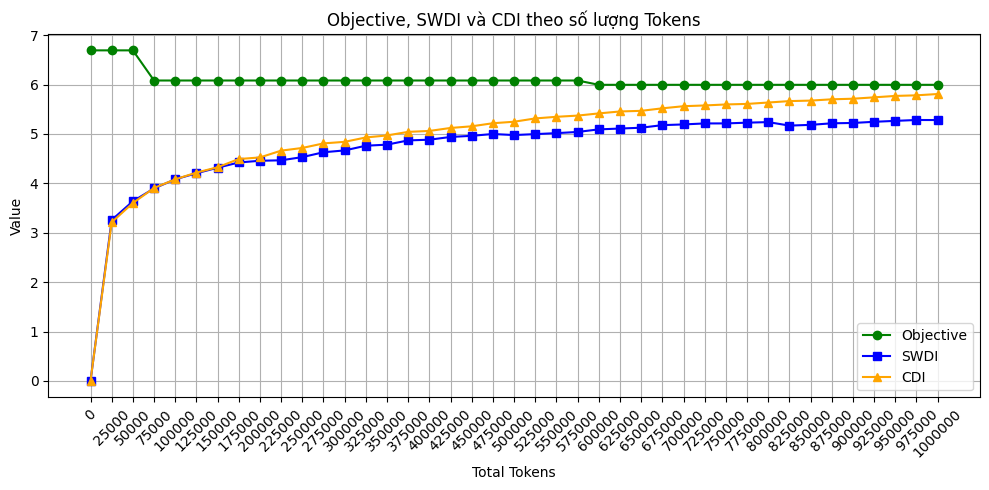

In [11]:
import matplotlib.pyplot as plt

# Ép tokens thành kiểu int
tokens = [int(x[0]) for x in nearest_objs]
objs = [x[1] for x in nearest_objs]
SWDI = [x[2] for x in nearest_objs]
CDI = [x[3] for x in nearest_objs]

plt.figure(figsize=(10, 5))

plt.plot(tokens, objs, marker='o', label='Objective', color='green')
plt.plot(tokens, SWDI, marker='s', label='SWDI', color='blue')
plt.plot(tokens, CDI, marker='^', label='CDI', color='orange')

plt.xlabel('Total Tokens')
plt.ylabel('Value')
plt.title('Objective, SWDI và CDI theo số lượng Tokens')
plt.xticks(tokens, rotation=45)  # Đảm bảo matplotlib hiển thị đúng tokens
plt.ticklabel_format(style='plain', axis='x')  # <--- không dùng định dạng khoa học (1e6)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()